# Model development

For my model, the lack of correlations identified in the heatmap and scatterplots indicates that no variables are substantially more correlated with SVI than other metrics. Therefore, all metrics were retained for the model.

A model capable of making predictions from time series data was essential for this project. I chose to use the random forest model because it meets these requirements, can adapt to non-linear patterns, resistant to overfitting, can handle seasonal trends, and is simpler than other options.

I used TimeSeriesSplit as a cross-validator because it is specifically designed for time series data. The dataset is split into consecutive folds, where each fold is a superset of the previous one, ensuring that the model is trained on data that retains the temporal nature of time series data. In addition, these methods can also check for autocorrelation.

Optimization was not thoroughly explored for this first version of the model. Performance can be increased in future versions by experimenting with different hyperparameter values for the RandomForestRegressor (e.g., n_estimators, max_depth, min_samples_split) and by adjusting the number of splits in TimeSeriesSplit. Trying different lag values or determining lag values based on data analysis could be performed for future versions of the model in order to determine the time periods that are most predictive.

The MSEs from the three lagged datasets indicate that the model is better at predicting the SVI one week into the future than two or three weeks.

In [2]:
# Libraries imported for this project

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.metrics import mean_squared_error

In [4]:
# Read EDA_Data.xlsx into a dataframe, formatted dates, and indexed dates.

df = pd.read_excel('/Users/NJahns/Desktop/Bootcamp/Capstone_Two/Edited_Data/EDA_Data.xlsx', parse_dates=True, index_col=[0])

In [26]:
# Created dataframes for each set of lagged metrics.

df_lag_7 = df.filter(like='_lag_7').assign(**{'Sludge Volume Index': df['Sludge Volume Index']})
df_lag_14 = df.filter(like='_lag_14').assign(**{'Sludge Volume Index': df['Sludge Volume Index']})
df_lag_21 = df.filter(like='_lag_21').assign(**{'Sludge Volume Index': df['Sludge Volume Index']})

print("\nDataFrame for df_lag_7:\n")
for column_title in df_lag_7.columns:
    print(column_title)
    
print("\nDataFrame for df_lag_14:\n")
for column_title in df_lag_14.columns:
    print(column_title)
    
print("\nDataFrame for df_lag_21:\n")
for column_title in df_lag_21.columns:
    print(column_title)


DataFrame for df_lag_7:

Sludge Volume Index_lag_7
SE NH3_lag_7
MLSS_lag_7
RAS TSS_lag_7
Alum Feed 1_lag_7
Alum Feed 2_lag_7
WAS Flow_lag_7
Primary Sludge A Flow_lag_7
Primary Sludge B Flow_lag_7
F:M Ratio_lag_7
Ana F:M_lag_7
RAS Flow_lag_7
Avg ND Effluent Hourly Ammonia_lag_7
Avg ND WAS Flow_lag_7
Avg ND Aeration DO Cell 5 AVG_lag_7
Avg ND Aeration DO Cell 7 AVG_lag_7
Avg ND Aer. Avg Cell 7 Nitrate_lag_7
Avg ND Average Basin Airflow_lag_7
Sludge Volume Index

DataFrame for df_lag_14:

Sludge Volume Index_lag_14
SE NH3_lag_14
MLSS_lag_14
RAS TSS_lag_14
Alum Feed 1_lag_14
Alum Feed 2_lag_14
WAS Flow_lag_14
Primary Sludge A Flow_lag_14
Primary Sludge B Flow_lag_14
F:M Ratio_lag_14
Ana F:M_lag_14
RAS Flow_lag_14
Avg ND Effluent Hourly Ammonia_lag_14
Avg ND WAS Flow_lag_14
Avg ND Aeration DO Cell 5 AVG_lag_14
Avg ND Aeration DO Cell 7 AVG_lag_14
Avg ND Aer. Avg Cell 7 Nitrate_lag_14
Avg ND Average Basin Airflow_lag_14
Sludge Volume Index

DataFrame for df_lag_21:

Sludge Volume Index_lag_

In [61]:
# Defined target and explanatory metrics for each lagged dataframe.

target_metric = 'Sludge Volume Index'
explanatory_metrics_7 = [col for col in df_lag_7.columns if col != target_metric]
explanatory_metrics_14 = [col for col in df_lag_14.columns if col != target_metric]
explanatory_metrics_21 = [col for col in df_lag_21.columns if col != target_metric]

In [62]:
# Defined random forest regressor model.

model_lag_7 = RandomForestRegressor()
model_lag_14 = RandomForestRegressor()
model_lag_21 = RandomForestRegressor()

In [63]:
# Defined TimeSeriesSplit with 5 splits.

tscv_lag_7 = TimeSeriesSplit(n_splits=5)
tscv_lag_14 = TimeSeriesSplit(n_splits=5)
tscv_lag_21 = TimeSeriesSplit(n_splits=5)

In [66]:
# Performed cross-validated predictions for each lagged dataframe.

mse_scores_7 = -cross_val_score(model_lag_7, df_lag_7[explanatory_metrics_7], df_lag_7[target_metric], cv=tscv_lag_7, scoring='neg_mean_squared_error')
mse_scores_14 = -cross_val_score(model_lag_14, df_lag_14[explanatory_metrics_14], df_lag_14[target_metric], cv=tscv_lag_14, scoring='neg_mean_squared_error')
mse_scores_21 = -cross_val_score(model_lag_21, df_lag_21[explanatory_metrics_21], df_lag_21[target_metric], cv=tscv_lag_21, scoring='neg_mean_squared_error')

In [67]:
# Printed the mean squared error scores for each fold for each lagged dataframe.

print('Mean Squared Error for df_lag_7')  
for i, mse_score in enumerate(mse_scores_7):
    print(f'Fold {i + 1}: {mse_score}')
print()

print('Mean Squared Error for df_lag_14')    
for i, mse_score in enumerate(mse_scores_14):
    print(f'Fold {i + 1}: {mse_score}')
print() 

print('Mean Squared Error for df_lag_21')    
for i, mse_score in enumerate(mse_scores_21):
    print(f'Fold {i + 1}: {mse_score}')

Mean Squared Error for df_lag_7
Fold 1: 58.75062793754873
Fold 2: 197.13058347692555
Fold 3: 333.65925257461583
Fold 4: 198.2972666096892
Fold 5: 129.8421626581096

Mean Squared Error for df_lag_14
Fold 1: 77.97287889740367
Fold 2: 262.10527943211747
Fold 3: 352.5254044686207
Fold 4: 209.63689506868073
Fold 5: 140.60657686091514

Mean Squared Error for df_lag_21
Fold 1: 170.98095237066806
Fold 2: 357.6706826133238
Fold 3: 352.6955468652792
Fold 4: 299.5714806683636
Fold 5: 194.1157994992106


In [68]:
# Trained the model on the entire dataset for each lagged dataframe.
model_lag_7.fit(df_lag_7[explanatory_metrics_7], df_lag_7[target_metric])
model_lag_14.fit(df_lag_14[explanatory_metrics_14], df_lag_14[target_metric])
model_lag_21.fit(df_lag_21[explanatory_metrics_21], df_lag_21[target_metric])

RandomForestRegressor()

In [69]:
# Made predictions on the entire dataset for each lagged dataframe.
y_pred_7 = model_lag_7.predict(df_lag_7[explanatory_metrics_7])
y_pred_14 = model_lag_14.predict(df_lag_14[explanatory_metrics_14])
y_pred_21 = model_lag_21.predict(df_lag_21[explanatory_metrics_21])

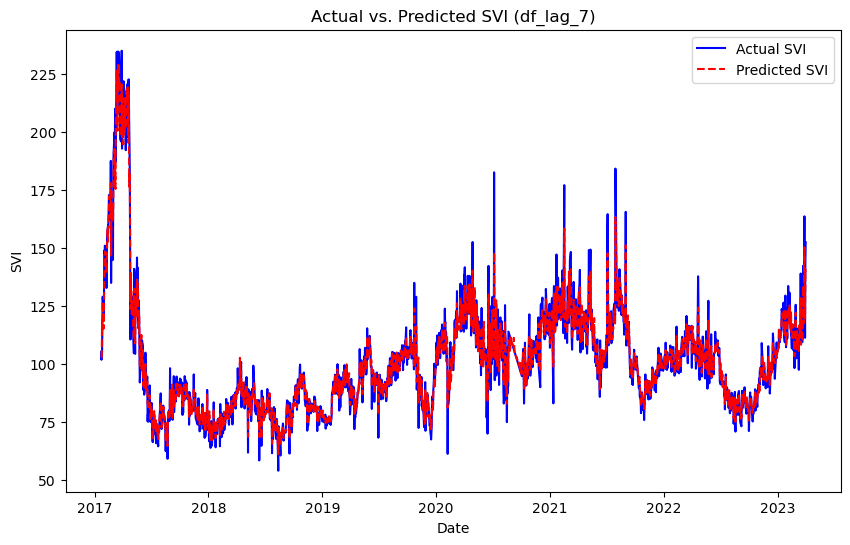

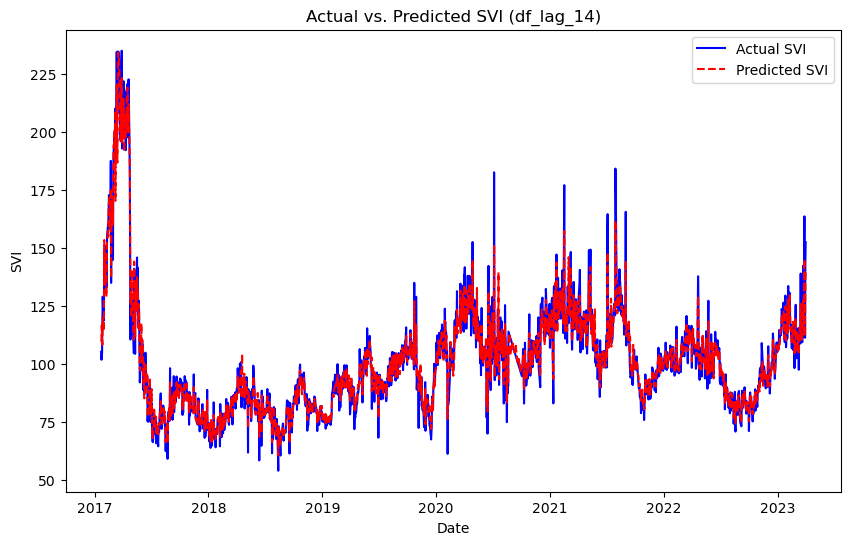

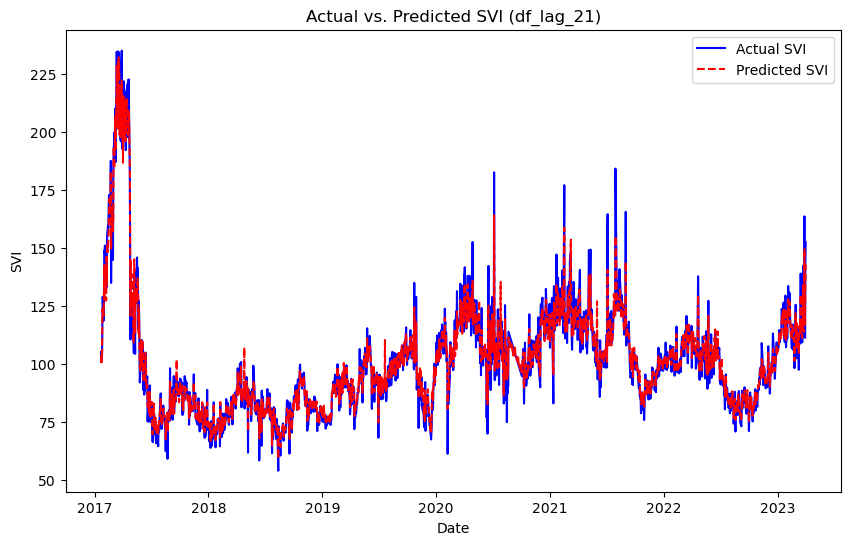

In [70]:
# Plotted actual vs. predicted values for each lagged dataframe.
plt.figure(figsize=(10, 6))
plt.plot(df_lag_7.index, df_lag_7[target_metric], label='Actual SVI', color='blue')
plt.plot(df_lag_7.index, y_pred_7, label='Predicted SVI', color='red', linestyle='dashed')
plt.xlabel('Date')
plt.ylabel('SVI')
plt.title('Actual vs. Predicted SVI (df_lag_7)')
plt.legend()
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(df_lag_14.index, df_lag_14[target_metric], label='Actual SVI', color='blue')
plt.plot(df_lag_14.index, y_pred_14, label='Predicted SVI', color='red', linestyle='dashed')
plt.xlabel('Date')
plt.ylabel('SVI')
plt.title('Actual vs. Predicted SVI (df_lag_14)')
plt.legend()
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(df_lag_21.index, df_lag_21[target_metric], label='Actual SVI', color='blue')
plt.plot(df_lag_21.index, y_pred_21, label='Predicted SVI', color='red', linestyle='dashed')
plt.xlabel('Date')
plt.ylabel('SVI')
plt.title('Actual vs. Predicted SVI (df_lag_21)')
plt.legend()
plt.show()

In [71]:
# Evaluated model performance for each lagged dataframe.
mse_7 = mean_squared_error(df_lag_7[target_metric], y_pred_7)
print(f'Mean Squared Error (df_lag_7): {mse_7}')

mse_14 = mean_squared_error(df_lag_14[target_metric], y_pred_14)
print(f'Mean Squared Error (df_lag_14): {mse_14}')

mse_21 = mean_squared_error(df_lag_21[target_metric], y_pred_21)
print(f'Mean Squared Error (df_lag_21): {mse_21}')

Mean Squared Error (df_lag_7): 13.959363378015723
Mean Squared Error (df_lag_14): 14.25783281214072
Mean Squared Error (df_lag_21): 16.274143715194437


# Data save

In [ ]:
# Saved to Excel.
EPA_df.to_excel('/Users/NJahns/Desktop/Bootcamp/Capstone_Two/Edited_Data/Model_Data,xlsx', index=True)